In [1]:
#impotring libraries and iris dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
iris = load_iris()

In [3]:
iris = pd.DataFrame(data= np.c_[iris['data'], iris['target']],
                     columns= iris['feature_names'] + ['target'])

In [4]:
iris

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [6]:
#Standardization
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [7]:
X = sc.fit_transform(iris)

In [8]:
#appy the PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

In [11]:
pca_sc = pca.fit_transform(X)

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

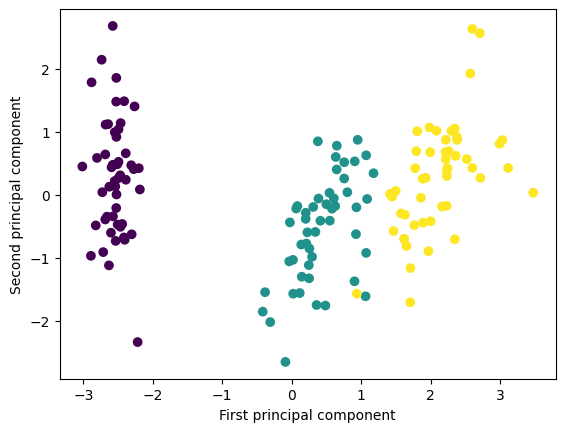

In [13]:
plt.scatter(pca_sc[:,0],pca_sc[:,1], c=iris['target'])
plt.xlabel('First principal component')
plt.ylabel('Second principal component')
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

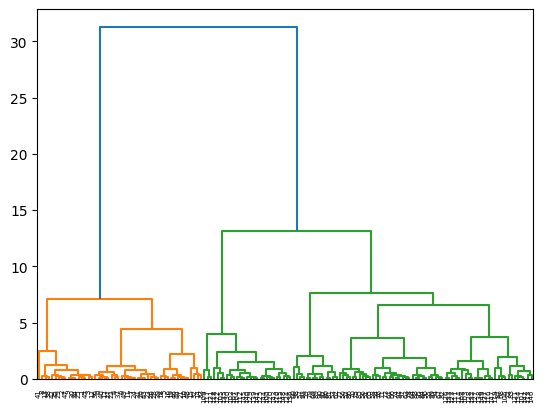

In [14]:
# Agglomerative Clustering
# Construct Dendogram

import scipy.cluster.hierarchy as sch
dendogram = sch.dendrogram(sch.linkage(pca_sc, method='ward'))
plt

In [18]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
hc.fit(pca_sc)

AgglomerativeClustering()

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

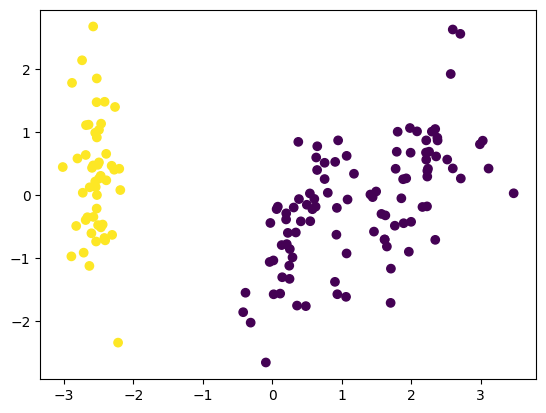

In [19]:
plt.scatter(pca_sc[:,0],pca_sc[:,1], c=hc.labels_)
plt

In [20]:
# DBSCAN clustering
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

In [51]:
X,y=make_moons(n_samples=250, noise=0.1)

In [52]:
X

array([[ 1.84797078e+00, -7.97470161e-02],
       [ 5.92347563e-01,  1.03759875e+00],
       [ 1.43396699e-01, -8.06794427e-02],
       [ 6.09677851e-02,  1.29748003e-01],
       [ 1.38820371e+00, -3.36965667e-01],
       [-9.34570297e-01,  1.36572066e-01],
       [ 4.13046344e-01, -4.93906728e-01],
       [-8.16196705e-01,  5.92969543e-01],
       [ 4.07085321e-01,  7.80670646e-01],
       [ 1.97636187e+00,  3.85587514e-01],
       [ 5.50397190e-01, -1.98025648e-01],
       [ 1.89541796e+00,  1.41015287e-01],
       [-6.45181922e-01,  8.55001207e-01],
       [-8.98479112e-01,  4.75706607e-01],
       [ 1.80813766e+00, -1.80393268e-01],
       [-1.31008116e-01,  8.91684768e-01],
       [ 1.01880199e-01,  9.71895705e-01],
       [ 1.00990494e-01,  1.23478981e-01],
       [ 1.05901921e+00,  2.51371247e-01],
       [ 1.01486820e+00,  1.36424810e-01],
       [-9.38266966e-01,  1.24809886e-01],
       [ 1.78018664e+00,  3.60098626e-01],
       [ 7.97285343e-02,  2.74468867e-01],
       [ 1.

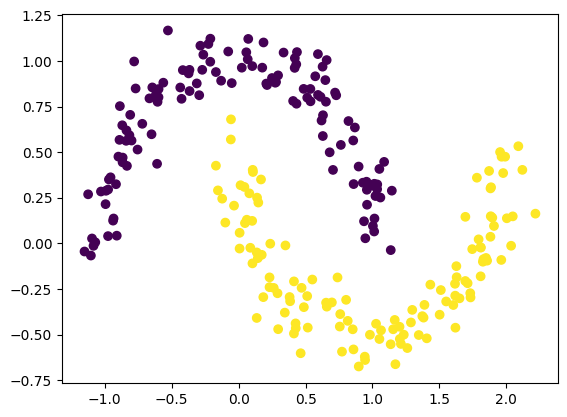

In [53]:
plt.scatter(X[:,0],X[:,1], c=y)


In [54]:
# Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_sc = sc.fit_transform(X)

In [55]:
X_sc

array([[ 1.53868062, -0.64477733],
       [ 0.11058341,  1.55528155],
       [-0.40003592, -0.64661328],
       [-0.49378737, -0.23228069],
       [ 1.01575936, -1.15124202],
       [-1.62607382, -0.21884408],
       [-0.09334685, -1.46025968],
       [-1.49144028,  0.67980462],
       [-0.10012669,  1.04938895],
       [ 1.68470768,  0.27146847],
       [ 0.06287068, -0.87766849],
       [ 1.5926452 , -0.21009535],
       [-1.29693469,  1.19574616],
       [-1.58502511,  0.44891337],
       [ 1.49337598, -0.84295026],
       [-0.71213332,  1.26797625],
       [-0.44725518,  1.42591195],
       [-0.44826709, -0.24462442],
       [ 0.64135766,  0.00719603],
       [ 0.59114201, -0.21913403],
       [-1.63027827, -0.24200386],
       [ 1.46158556,  0.22128073],
       [-0.47244962,  0.05267535],
       [ 1.31366035, -1.08056737],
       [ 1.57674068, -0.41608389],
       [-0.07346003,  1.4452493 ],
       [-0.08698061,  1.40652794],
       [ 1.76630688, -0.19587713],
       [-1.24401836,

In [56]:
db = DBSCAN(eps=0.2)
db.fit(X_sc)

DBSCAN(eps=0.2)

In [57]:
db.labels_

array([ 0,  3,  1,  1,  0,  2,  0,  2,  3,  4,  0,  0,  3,  2,  0,  3,  3,
        1,  5,  5,  2,  4,  1,  0,  0,  3,  3,  0,  3,  0,  1,  0,  5,  0,
        1,  3,  0,  0,  1,  0,  0,  0,  3, -1, -1,  5,  5, -1, -1, -1,  0,
        4,  0,  3,  3,  3,  2,  5,  0, -1,  1,  0,  2,  5,  0,  1,  0,  2,
        6,  0,  3,  3,  0,  0,  1,  0,  2,  0,  5, -1,  0,  0,  5,  0,  0,
        0,  1,  0,  0,  3,  5,  3,  0,  2,  0,  2, -1,  0,  3,  2,  1,  3,
        0,  2,  1,  3,  0,  0,  2,  2,  1,  3,  3,  3,  0,  0,  2,  3,  3,
        3,  3, -1,  0,  3,  2,  3,  2,  0,  3,  3,  2,  4,  6,  3,  0,  0,
        4,  3,  3,  3,  3,  4, -1,  4,  2,  0,  0,  0,  0,  5,  5,  0,  3,
        1,  4,  2,  1,  5, -1,  1,  0,  2,  0, -1,  4,  3,  0,  3,  6,  0,
        0,  0,  0,  0,  1,  6,  3,  3,  0,  0,  2,  0,  3, -1,  0,  0,  3,
        4,  0,  5,  0,  3,  2,  0,  0,  5,  3,  2,  5,  3,  1,  2,  0,  5,
        2,  3,  3, -1,  0,  3,  3,  2,  3,  6,  3, -1, -1,  1,  3, -1,  3,
        0,  3,  5,  0,  5

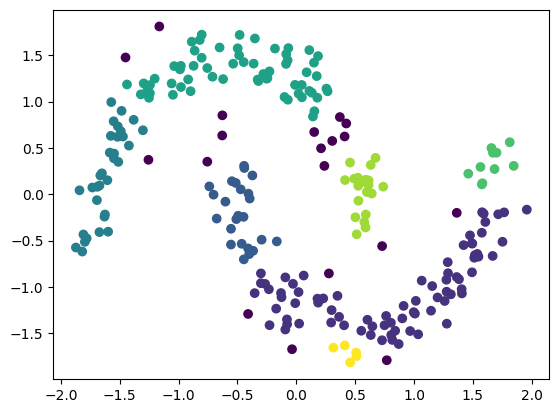

In [58]:
plt.scatter(X_sc[:,0],X_sc[:,1], c=db.labels_)
